- [ ] Weisslicht Bild erzeugen entweder direkte Summe oder besser gewichtet mit $\omega = 1/\sigma$ 
- [ ] Gewichtet: $\frac{\Sigma f_i*\omega_i}{\Sigma \omega_i}$ : Dafür muss ich mir noch den signifikanz cube ziehen. Vielleicht habe ich den aber auch schon
- [ ] Helle flecken sollten die Sterne sein um sicher zu gehen kann ich das ganze auch für viele Sterne machen und dann gemittelte Paramter nehmen
- [ ] Cube in $\lambda$ bins aufteilen und je bin ein narrow band bild machen
- [ ] Aus dem NB ein 2D model fitten an den Stern
	- [ ] 2D Gauss 
	- [ ] 2D Moffat $f(x,y;\alpha,\beta) = \frac{\beta - 1}{\pi \alpha^2}\left[1 + \frac{x^2 + y^2}{\alpha^2}\right]^{-\beta}$
- [ ] FWHM gegen $\lambda$ plotten und Potentz Gesetz fitten evtl: $FWHM(\lambda) = FWHM_0 * \left(\frac{\lambda}{\lambda_0}\right)^\alpha$  alternativ ein Polynom

$FWHM = \alpha \sqrt{2^{1/\beta} - 1}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from scipy.optimize import curve_fit

In [2]:
def wave_to_idx(lamda, wave_start=3470, wave_step=2):
    t = []
    for wl_min, wl_max in lamda:
        idx_start = int(np.round((wl_min - wave_start) / wave_step))
        idx_end = int(np.round((wl_max - wave_start) / wave_step)) + 1
        
        t.append((idx_start, idx_end))
    return t

In [3]:
bad_wl_ranges = [[4648,4686],[4854, 4868], [5140,5144], [5170, 5210]] # shows lots of spurious signal in both fields

bad_idxs = wave_to_idx(bad_wl_ranges)
bad_idxs

[(589, 609), (692, 700), (835, 838), (850, 871)]

In [4]:
with fits.open("/Users/bene/Desktop/mpe/fits/cube.fits") as hdul:
    data = hdul[0].data
    header = hdul[0].header

In [5]:
# crval3 = header['CRVAL3']
# cdelt3 = header.get('CDELT3', header.get('CD3_3', 1.0)) 

# nz = data.shape[0]  

# wave = crval3 + np.arange(nz) * cdelt3

# mask = np.zeros(data.shape[0], dtype=bool)

# for wl_min, wl_max in bad_wl_ranges:
#     mask |= (wave >= wl_min) & (wave <= wl_max)

# data_clean = data.copy()
# #data_clean[mask, :, :] = np.nan

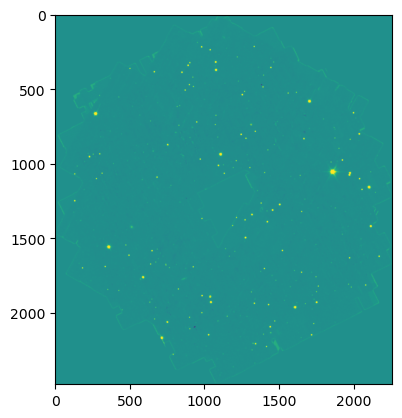

In [6]:
# image = np.nanmean(data, axis=0)
# image_clean = np.nanmean(data_clean, axis=0)

# np.save("./image.npy", image)
# np.save("./image_clean.npy", image_clean)

image = np.load("./image.npy")
image_clean = np.load("./image_clean.npy")
plt.imshow(image_clean,
           vmax=0.5,
           vmin=-0.5)

In [7]:
# %matplotlib qt

In [8]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# plt.imshow(image_clean, cmap="gray", origin="lower", vmax=0.5, vmin=-0.5)

# # n=-1 sammelt unbegrenzt Klicks:
# # - Linksklick: Punkt hinzufügen
# # - Rechtsklick: Letzten Punkt löschen
# # - Mittelklick (oder Enter): Beenden
# points = plt.ginput(n=-1, timeout=0)

# plt.close()

# print("Geklickte Koordinaten:", points)

In [9]:
# %matplotlib inline

In [10]:
# import numpy as np
# from photutils.centroids import centroid_sources, centroid_2dg

# # Annahme:
# # data: dein 2D-Bild
# # x_clicks, y_clicks: Listen oder Arrays deiner geklickten Punkte
# x_clicks = [p[0] for p in points]
# y_clicks = [p[1] for p in points]

# # box_size: Ungerade Zahl, passend zum Durchmesser des Sterns (z. B. 9, 11 oder 15)
# # centroid_func=centroid_2dg fittet ein 2D-Gaußprofil (sehr robust gegen Rauschen)
# # Alternativ: centroid_func=centroid_com (reiner Schwerpunkt / Center of Mass)
# x_cen, y_cen = centroid_sources(
#     image_clean, 
#     x_clicks, 
#     y_clicks, 
#     box_size=15, 
#     centroid_func=centroid_2dg
# )

In [11]:
# plt.figure(figsize=(10, 8))
# plt.imshow(image_clean, cmap="gray", origin="lower", vmax=0.5, vmin=-0.5)
# plt.scatter(x_cen, y_cen, facecolors='none', edgecolors='red', s=80, lw=1.5, label="Detektierte Sterne")
# plt.colorbar(label="Intensität")
# plt.legend()
# #plt.title(f"{len(sources)} Sterne erkannt (DAOStarFinder)")
# plt.show()

In [12]:
# stars = [(x_cen[i], y_cen[i]) for i in range(len(x_cen))]
# stars = np.array(stars)
# np.save("./stars_touple.npy", stars)
stars = np.load("./stars_touple.npy")

In [13]:
stars

array([[1107.35070164,  938.53359374],
       [1701.30293301,  584.48615548],
       [1605.26372504, 1963.61010602],
       [1272.95983393, 1497.32771419],
       [1316.7351887 , 1342.10434893],
       [1419.46015793, 1390.95995231],
       [1748.78834622, 1929.85885188],
       [ 663.67726125,  386.14516026],
       [ 751.07495271, 2062.56334545],
       [ 753.34310269,  874.35838468],
       [ 681.90807031, 1092.08787189],
       [1438.90692709, 2093.9144732 ],
       [1027.01776029, 2147.61848057],
       [1502.27666097, 1275.51336284],
       [1969.40048939, 1632.33506414],
       [2167.26398851, 1622.15895676],
       [1244.64982244,  805.29809552],
       [ 970.812018  ,  971.43693831],
       [ 848.48382022,  389.50137369],
       [ 980.30222226,  219.42462721],
       [ 648.40728369, 1584.94730754],
       [ 494.48158236, 1614.74370242],
       [ 230.1406577 ,  954.58602304],
       [1520.28355896, 1583.26659663],
       [1399.64299347, 1703.79997346]])

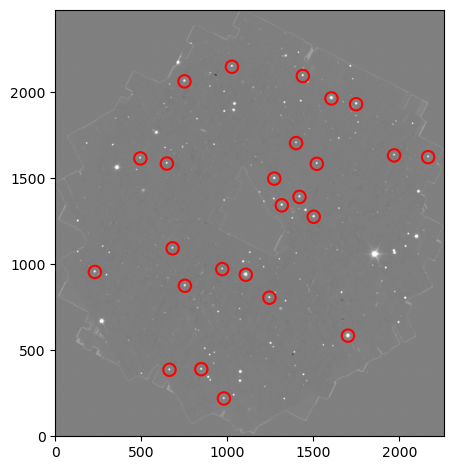

In [14]:
image = np.load("./image.npy")
image_clean = np.load("./image_clean.npy")
plt.imshow(image_clean,
           vmax=0.5,
           vmin=-0.5,
           origin="lower",
           cmap="grey")

for i in range(len(stars)):
    plt.scatter(stars[i][0], stars[i][1], facecolors="none", edgecolors="red", s=80, lw=1.5)

plt.tight_layout()
plt.savefig("./selected_stars.pdf")
plt.show()

In [15]:
# from astropy.nddata import Cutout2D

# x_z = 359
# y_z = 1558

# cutout = Cutout2D(image, position=(x_z, y_z), size=(29, 29))

# cutout_image = cutout.data

# plt.imshow(cutout_image)

In [16]:
# import numpy as np
# from astropy.modeling import models, fitting

# # 1. 2D-Moffat Modellerstellung
# # x_0, y_0: Zentrum der Punktquelle im Spaxel-Gitter
# moffat_init = models.Moffat2D(
#     amplitude=100.0, 
#     x_0=15.5, 
#     y_0=15.5, 
#     gamma=2.5,   # entspricht alpha in der Standard-Notation
#     alpha=2.8    # entspricht beta in der Standard-Notation bei astropy!
# )

# fitter = fitting.LevMarLSQFitter()

# y, x = np.mgrid[:29, :29]
# fitted_moffat = fitter(moffat_init, x, y, cutout_image)

# # 4. FWHM berechnen
# alpha_fit = fitted_moffat.gamma.value
# beta_fit = fitted_moffat.alpha.value

# fwhm_pixels = 2 * alpha_fit * np.sqrt(2**(1 / beta_fit) - 1)

# # In Bogensekunden umrechnen (falls spaxel_scale bekannt ist, z.B. 0.2"/pixel)
# spaxel_scale = 0.5 # "/pixel
# fwhm_arcsec = fwhm_pixels * spaxel_scale

In [17]:
# print(fwhm_arcsec)

In [18]:
# import astropy.units as u
# from astropy.coordinates import SkyCoord
# from astropy.wcs import WCS
# from astroquery.gaia import Gaia

# wcs = WCS(header, naxis=2)  # naxis=2
# ny, nx = data.shape[1], data.shape[2]

# ra_center, dec_center = wcs.all_pix2world(nx / 2, ny / 2, 0)
# center_coord = SkyCoord(
#     ra=ra_center, dec=dec_center, unit=(u.deg, u.deg), frame="icrs"
# )

# corner_ra, corner_dec = wcs.all_pix2world(0, 0, 0)
# fov_radius = (
#     center_coord.separation(
#         SkyCoord(ra=corner_ra, dec=corner_dec, unit=(u.deg, u.deg))
#     )
#     * 1.05
# )

# query = f"""
# SELECT source_id, ra, dec, phot_g_mean_mag, bp_rp, ruwe
# FROM gaiadr3.gaia_source
# WHERE 1 = CONTAINS(
#     POINT('ICRS', ra, dec),
#     CIRCLE('ICRS', {center_coord.ra.deg}, {center_coord.dec.deg}, {fov_radius.deg})
# )
# AND phot_g_mean_mag BETWEEN 15.0 AND 19.5
# AND ruwe < 1.2
# """

# job = Gaia.launch_job_async(query)
# stars_table = job.get_results()

# star_coords = SkyCoord(
#     ra=stars_table["ra"], dec=stars_table["dec"], unit=(u.deg, u.deg)
# )
# x_pix, y_pix = wcs.all_world2pix(star_coords.ra.deg, star_coords.dec.deg, 0)

# stars_table["x"] = x_pix
# stars_table["y"] = y_pix

In [19]:
# margin = 15
# mask_inside = (
#     (stars_table["x"] >= margin)
#     & (stars_table["x"] < nx - margin)
#     & (stars_table["y"] >= margin)
#     & (stars_table["y"] < ny - margin)
#     & (stars_table["phot_g_mean_mag"] < 19.5)
#     & (stars_table["phot_g_mean_mag"] > 17.5)
# )
# clean_stars = stars_table[mask_inside]

In [20]:
#clean_stars = Table.read("./clean_stars.fits")

In [21]:
bin_edges = np.linspace(0+300, data.shape[0]-500, 6 + 1, dtype=int)
bin_edges

array([300, 339, 378, 418, 457, 496, 536])

In [22]:
import numpy as np
from astropy.nddata import Cutout2D
from astropy.stats import sigma_clipped_stats
from photutils.centroids import centroid_2dg

ny, nx = data.shape[1], data.shape[2]

num_slabs = 6
bin_edges = np.linspace(0+50, data.shape[0]-50, num_slabs + 1, dtype=int)

central_indices = [(bin_edges[i] + bin_edges[i + 1]) // 2 for i in range(num_slabs)]


N = len(stars)  # Anzahl der Quellen
positions = [(stars[i][0], stars[i][1]) for i in range(N)]

narrow_band_images = [[] for _ in range(N)]

for i in range(num_slabs):
    idx_start = bin_edges[i]
    idx_end = bin_edges[i + 1]

    idx_center = central_indices[i]
    
    for n in range(N):
        x_c, y_c = positions[n]
        x0, y0 = int(round(x_c)), int(round(y_c))
        half = 15

        x_min, x_max = max(0, x0-half), min(nx, x0+half)
        y_min, y_max = max(0, y0-half), min(ny, y0+half)

        if x_min >= x_max or y_min >= y_max:
            continue

        half_ = 5
        #sub_cube = data[idx_start:idx_end, y_min:y_max, x_min:x_max]
        sub_cube = data[idx_center-half_:idx_center+half_, y_min:y_max, x_min:x_max]
        #slab_image = np.nanmean(sub_cube, axis=0)
        slab_image , _, _ = sigma_clipped_stats(
            sub_cube, sigma=3., maxiters=5, axis=0
            )
        
        default_pos = (x_c - x_min, y_c - y_min)

        # Zentroid bestimmen
        try:
            fit_x, fit_y = centroid_2dg(slab_image)
        except Exception:
            fit_x, fit_y = np.nan, np.nan

        # Absicherung: Liegt das gefittete Zentrum innerhalb des Bildes und ist nicht NaN?
        h_slab, w_slab = slab_image.shape
        if np.isfinite(fit_x) and np.isfinite(fit_y) and (0 <= fit_x < w_slab) and (0 <= fit_y < h_slab):
            local_pos = (fit_x, fit_y)
        else:
            local_pos = default_pos

        # Cutout durchführen
        cutout = Cutout2D(
            slab_image, 
            position=local_pos, 
            mode="partial", 
            size=(29, 29),
            fill_value=np.nan
        )
        narrow_band_images[n].append(cutout.data)

# Stacking the stars for testing

In [23]:
# narrow_band_images = np.nanmean(narrow_band_images, axis=0)
# for i in range(len(narrow_band_images)):
#     plt.imshow(narrow_band_images[i])
#     plt.show()

In [24]:
import numpy as np
from photutils.centroids import centroid_2dg
from astropy.modeling import models, fitting

fitter = fitting.LevMarLSQFitter()
try:
    ny_cut, nx_cut = narrow_band_images[0][0].shape
except Exception:
    ny_cut, nx_cut = narrow_band_images[0].shape
y, x = np.mgrid[:ny_cut, :nx_cut]

fwhm_all_stars = []

num = len(stars)

for n in range(num):
    fwhm_n = []
    for i in range(num_slabs):
        if num == 1:
            img = narrow_band_images[i].copy()
        else:
            img = narrow_band_images[n][i].copy()
        
        if img is None or np.isnan(img).all():
            fwhm_n.append(np.nan)
            continue
            
        img = np.nan_to_num(img, nan=np.nanmedian(img))
        bkg = np.nanmedian(img)
        amp = np.nanmax(img) - bkg
        
        if amp <= 0:
            fwhm_n.append(np.nan)
            continue
            
        # 1. Lokales Zentrum für diesen spezifischen Slab bestimmen (gleicht DCR aus)
        x_c, y_c = centroid_2dg(img - bkg)
        if not (0 <= x_c < nx_cut and 0 <= y_c < ny_cut):
            x_c, y_c = nx_cut / 2.0, ny_cut / 2.0

        # 2. Modell mit elastischeren Grenzen initialisieren
        moffat_init = models.Moffat2D(
            amplitude=amp,
            x_0=x_c,
            y_0=y_c,
            gamma=2.5,
            alpha=3.0,
            bounds={"gamma": (2, 6), "alpha": (2., 4.5)}
        ) + models.Const2D(amplitude=bkg)

        fitted_model = fitter(moffat_init, x, y, img, maxiter=1500)
        
        gamma_fit = fitted_model[0].gamma.value
        beta_fit = fitted_model[0].alpha.value
        
        # Gültigkeitsprüfung
        if beta_fit <= 1.0 or gamma_fit <= 0:
            fwhm_n.append(np.nan)
            continue
            
        fwhm_pix = 2.0 * gamma_fit * np.sqrt(2.0**(1.0 / beta_fit) - 1.0)
        fwhm_arcsec = fwhm_pix * 0.5  # 0.5"/px
        
        # Plausibilitätsfilter (Seeing zwischen 1.0" und 6.0")
        if 1.0 < fwhm_arcsec < 6.0:
            fwhm_n.append(fwhm_arcsec)
        else:
            fwhm_n.append(np.nan)
            
    fwhm_all_stars.append(fwhm_n)

fwhm_all_stars = np.array(fwhm_all_stars)

# Robuster Median über alle Sterne pro Slab
fwhm_mean = np.nanmean(fwhm_all_stars, axis=0)
fwhm_std = np.nanstd(fwhm_all_stars, axis=0)

crval3 = header["CRVAL3"]  # Startwellenlänge (z.B. 3470 Å)
cdelt3 = header.get("CDELT3", header.get("CD3_3", 2.0))  # Schrittweite pro Kanal (meist 2.0 Å)
nz = data.shape[0]  # Anzahl der spektralen Kanäle

wave = crval3 + np.arange(nz) * cdelt3

# 2. Zentrale Kanäle der Slabs bestimmen (passend zu deinem num_slabs)
bin_edges = np.linspace(0, nz, num_slabs + 1, dtype=int)
central_indices = [(bin_edges[i] + bin_edges[i + 1]) // 2 for i in range(num_slabs)]

# 3. Zentrale Wellenlängen für jeden Slab abgreifen
central_wavelengths = wave[central_indices]

In [25]:
from scipy.optimize import curve_fit

lam_0 = 4500

def model_psf(lam, fwhm_o, gamma):
    return fwhm_o * (lam / lam_0)**gamma

popt, _ = curve_fit(
    model_psf,
    central_wavelengths,
    fwhm_mean,
    p0=[3, -0.2]
    )

print(popt)

[ 1.77765197 -1.39079765]


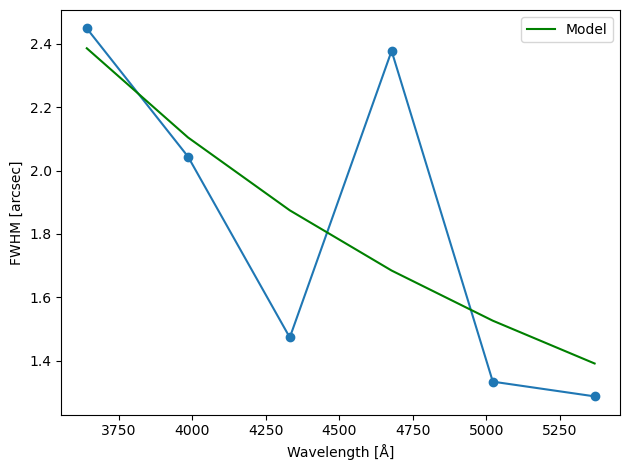

In [26]:
plt.plot(central_wavelengths, fwhm_mean, marker="o", color="C0")
plt.plot(central_wavelengths, model_psf(central_wavelengths, *popt), color="green", label="Model")
plt.xlabel("Wavelength [Å]")
plt.ylabel("FWHM [arcsec]")
plt.legend()
plt.tight_layout()
plt.savefig("./psf.pdf")
plt.show()

In [25]:
from astropy.table import Table
import matplotlib.pyplot as plt

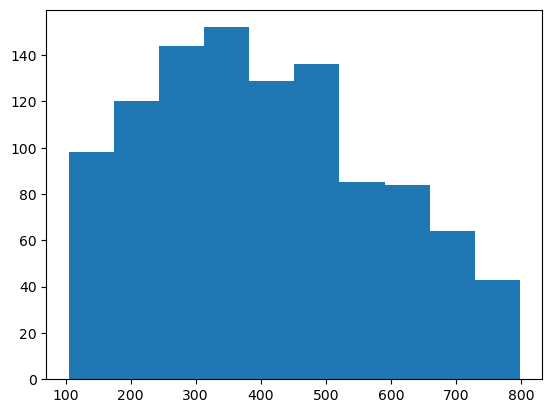

In [26]:
table = Table.read("Katalog_neu.fits")
mask = (table["FWHM"] > 100) & (table["FWHM"] < 800)
table = table[mask]
plt.hist(table["FWHM"])
plt.show()